In [47]:
import os
import caer
import numpy as np
import cv2 as cv
import gc
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alexattia/the-simpsons-characters-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Xian\.cache\kagglehub\datasets\alexattia\the-simpsons-characters-dataset\versions\4


In [48]:
IMG_SIZE = (80, 80)
channels = 1
char_path = os.path.join(path, "simpsons_dataset")

In [49]:
char_dict = {}
for char in os.listdir(char_path):
    char_dict[char] = len(os.listdir(os.path.join(char_path, char)))

#Sort in descending order
char_dict = caer.sort_dict(char_dict, descending=True)
char_dict

[('homer_simpson', 2246),
 ('ned_flanders', 1454),
 ('moe_szyslak', 1452),
 ('lisa_simpson', 1354),
 ('bart_simpson', 1342),
 ('marge_simpson', 1291),
 ('krusty_the_clown', 1206),
 ('principal_skinner', 1194),
 ('charles_montgomery_burns', 1193),
 ('milhouse_van_houten', 1079),
 ('chief_wiggum', 986),
 ('abraham_grampa_simpson', 913),
 ('sideshow_bob', 877),
 ('apu_nahasapeemapetilon', 623),
 ('kent_brockman', 498),
 ('comic_book_guy', 469),
 ('edna_krabappel', 457),
 ('nelson_muntz', 358),
 ('lenny_leonard', 310),
 ('mayor_quimby', 246),
 ('waylon_smithers', 181),
 ('maggie_simpson', 128),
 ('groundskeeper_willie', 121),
 ('barney_gumble', 106),
 ('selma_bouvier', 103),
 ('carl_carlson', 98),
 ('ralph_wiggum', 89),
 ('patty_bouvier', 72),
 ('martin_prince', 71),
 ('professor_john_frink', 65),
 ('snake_jailbird', 55),
 ('cletus_spuckler', 47),
 ('rainier_wolfcastle', 45),
 ('agnes_skinner', 42),
 ('simpsons_dataset', 42),
 ('sideshow_mel', 40),
 ('otto_mann', 32),
 ('fat_tony', 27),
 (

In [50]:
characters = []
count = 0
for i in char_dict:
    characters.append(i[0])
    count += 1
    if count >=10:
        break
characters


['homer_simpson',
 'ned_flanders',
 'moe_szyslak',
 'lisa_simpson',
 'bart_simpson',
 'marge_simpson',
 'krusty_the_clown',
 'principal_skinner',
 'charles_montgomery_burns',
 'milhouse_van_houten']

In [51]:
#Create training data
train = caer.preprocess_from_dir(char_path, characters, IMG_SIZE, channels=channels, isShuffle=True)   

[INFO] Could not find a file to load from. Generating the training data
----------------------------------------------
[INFO] At 1000 files
[INFO] At 2000 files
[INFO] 2246 files found in 0.006528139114379883s
[INFO] At 1000 files
[INFO] 1454 files found in 0.003052949905395508s
[INFO] At 1000 files
[INFO] 1452 files found in 0.0035140514373779297s
[INFO] At 1000 files
[INFO] 1354 files found in 0.003000020980834961s
[INFO] At 1000 files
[INFO] 1342 files found in 0.003564119338989258s
[INFO] At 1000 files
[INFO] 1291 files found in 0.0037012100219726562s
[INFO] At 1000 files
[INFO] 1206 files found in 0.001992464065551758s
[INFO] At 1000 files
[INFO] 1194 files found in 0.002995729446411133s
[INFO] At 1000 files
[INFO] 1193 files found in 0.002949237823486328s
[INFO] At 1000 files
[INFO] 1079 files found in 0.0030019283294677734s
----------------------------------------------
[INFO] 13811 files preprocessed! Took 0m 20s


In [52]:
len(train)

13811

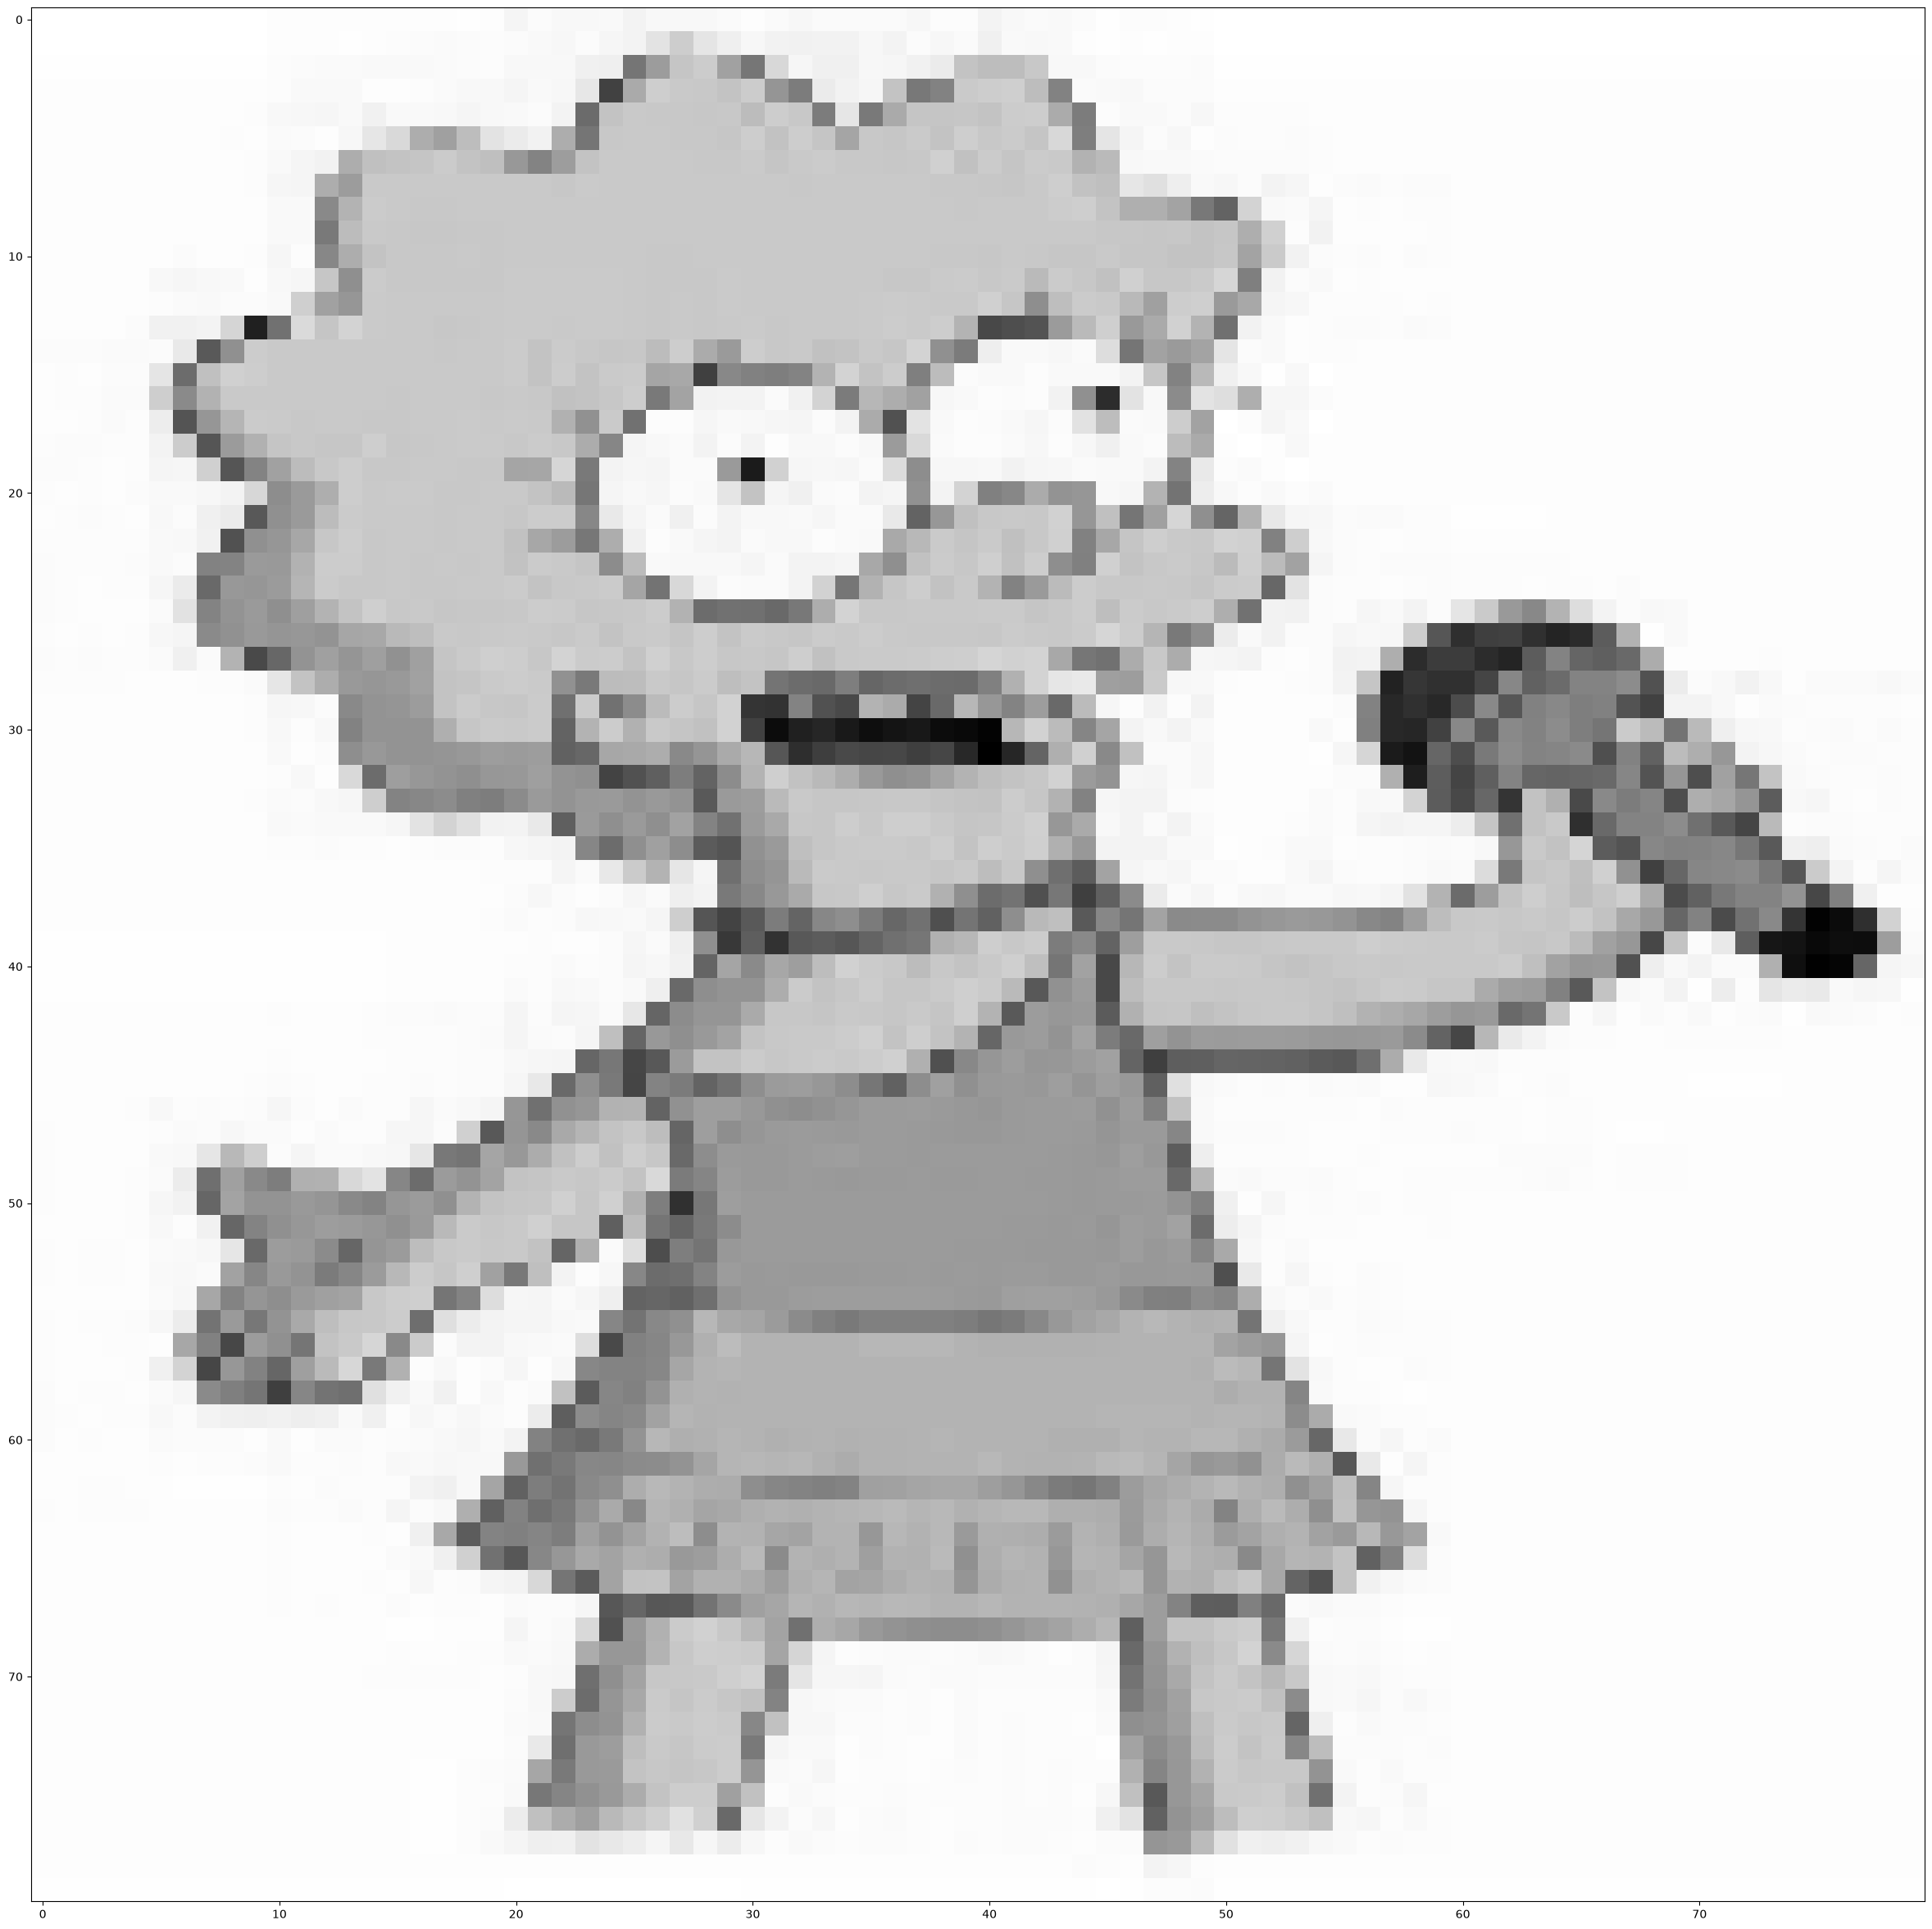

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 30))
plt.imshow(train[0][0], cmap='gray')
plt.show()

In [54]:
featureSet, labels = caer.sep_train(train, IMG_SIZE)

In [55]:
from tensorflow.keras.utils import to_categorical
#Normalize the feature set ==> (0, 1)
featureSet = caer.normalize(featureSet)
labels = to_categorical(labels, len(characters))

In [56]:
x_train, x_val, y_train, y_val = caer.train_val_split(featureSet, labels, val_ratio=0.2)

In [57]:
del train
del featureSet
del labels
gc.collect()

0

In [58]:
BATCH_SIZE = 32
EPOCHS = 10

In [67]:
import tensorflow as tf

# Modern TensorFlow replacement for imageDataGenerator
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

# Flow the data just like before
train_gen = datagen.flow(x_train, y_train, batch_size=BATCH_SIZE)

In [68]:
from tensorflow.keras import layers, models

# Recreating the Simpsons CNN Model architecture natively
model = models.Sequential([
    # Input Layer & First Conv Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE[0], IMG_SIZE[1], channels)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Second Conv Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Third Conv Block
    layers.Conv2D(124, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten & Dense Layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    
    # Output Layer (output_dim is the number of character classes)
    layers.Dense(len(characters), activation='softmax') 
])

# Compile the model with the tutorial's parameters
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy', # Changed to categorical since it's multi-class sorting
    metrics=['accuracy']
)

model.summary()

c:\Users\Xian\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 124)    │        71,548 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 124)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 124)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,349,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,444,806 (24.58 MB)

 Trainable params: 6,444,806 (24.58 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
from tensorflow.keras.callbacks import LearningRateScheduler

# 1. Define a native step-decay function to replace canaro's schedule
def lr_schedule(epoch):
    initial_lr = 0.001
    # Drops the learning rate down by 10% every 5 epochs
    if epoch > 0 and epoch % 5 == 0:
        return initial_lr * (0.1 ** (epoch // 5))
    return initial_lr

# 2. Pass our new native function into the scheduler
callbacks_list = [LearningRateScheduler(lr_schedule)]

In [74]:
training = model.fit(train_gen, 
                     steps_per_epoch=len(x_train) // BATCH_SIZE,
                     epochs=EPOCHS,
                     validation_data=(x_val, y_val),
                     validation_steps=len(y_val) // BATCH_SIZE,
                     callbacks=callbacks_list)

Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 124ms/step - accuracy: 0.1612 - loss: 2.2699 - val_accuracy: 0.1668 - val_loss: 2.2555 - learning_rate: 0.0010
Epoch 2/10
  1/345 ━━━━━━━━━━━━━━━━━━━━ 35s 103ms/step - accuracy: 0.2500 - loss: 2.2116

c:\Users\Xian\tf_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2500 - loss: 2.2116 - val_accuracy: 0.1668 - val_loss: 2.2552 - learning_rate: 0.0010
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 127ms/step - accuracy: 0.1956 - loss: 2.2000 - val_accuracy: 0.2232 - val_loss: 2.1687 - learning_rate: 0.0010
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2188 - loss: 2.0994 - val_accuracy: 0.2207 - val_loss: 2.1687 - learning_rate: 0.0010
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 127ms/step - accuracy: 0.2396 - loss: 2.1342 - val_accuracy: 0.2475 - val_loss: 2.1195 - learning_rate: 0.0010
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1562 - loss: 2.1489 - val_accuracy: 0.2471 - val_loss: 2.1204 - learning_rate: 1.0000e-04
Epoch 7/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - accuracy: 0.2608 - loss: 2.0919 - val_accuracy: 0.2732 - val_loss: 2.0748 - learning_rate: 0.0010
Epoch 8/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3750 - loss: 2.0118 

In [75]:
characters

['homer_simpson',
 'ned_flanders',
 'moe_szyslak',
 'lisa_simpson',
 'bart_simpson',
 'marge_simpson',
 'krusty_the_clown',
 'principal_skinner',
 'charles_montgomery_burns',
 'milhouse_van_houten']

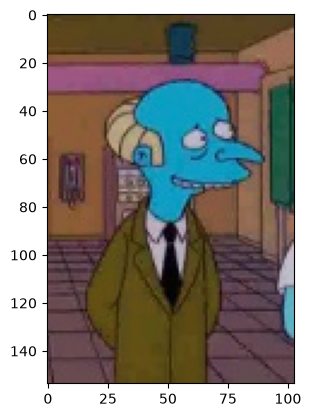

In [95]:
test_path = r"C:\Users\Xian\.cache\kagglehub\datasets\alexattia\the-simpsons-characters-dataset\versions\4\kaggle_simpson_testset\kaggle_simpson_testset\charles_montgomery_burns_0.jpg"
img = cv.imread(test_path)

plt.imshow(img)
plt.show()

In [96]:
def prepare (img):
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img = cv.resize(img, IMG_SIZE)
    img = caer.reshape(img, IMG_SIZE, 1)
    return img

In [97]:
predictions = model.predict([prepare(img)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [98]:
print(characters[np.argmax(predictions[0])])

lisa_simpson
